In [2]:
# ============================================================
# LLM Data Pipeline - Lab Assignment 5
# Modified version using: AG News dataset + DistilGPT2 tokenizer
#                         + block_size 256 + Train/Val split
# ============================================================

# Install dependencies
!pip install transformers datasets torch



In [3]:
# ---------------------------------------------------------------
# Imports
# ---------------------------------------------------------------
# WHY: We need:
#   - datasets: to download and manage NLP datasets from HuggingFace
#   - AutoTokenizer: to convert raw text into token IDs a model understands
#   - DataLoader: to batch and shuffle data efficiently during training
#   - torch: the deep learning framework everything is built on
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
import torch



In [4]:
# ---------------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------------
# ORIGINAL: used WikiText-2 (encyclopedia-style text)
# MODIFICATION: AG News — a news classification dataset.
#   I took only the 'train' split and use the 'text' column.
# WHY AG News: It's shorter, more varied in vocabulary,
#   and demonstrates that this pipeline works on real-world news text,
#   not just clean Wikipedia data.

dataset = load_dataset("ag_news", split="train")
print(f"Total examples in dataset: {len(dataset)}")
print(f"Column names: {dataset.column_names}")
print(f"Sample text: {dataset[0]['text'][:200]}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Total examples in dataset: 120000
Column names: ['text', 'label']
Sample text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [5]:
# ---------------------------------------------------------------
# Train / Validation Split
# ---------------------------------------------------------------
# ORIGINAL: Only used the 'train' split with no validation set.
# MODIFICATION: split 90% train / 10% validation.
# WHY: In real ML pipelines, you always need a validation set
#   to monitor overfitting and evaluate model performance during training.

split = dataset.train_test_split(test_size=0.1, seed=42)
train_data = split["train"]
val_data   = split["test"]
print(f"Train size: {len(train_data)}, Validation size: {len(val_data)}")



Train size: 108000, Validation size: 12000


In [6]:
#---------------------------------------------------------------
# Initialize Tokenizer
# ---------------------------------------------------------------
# ORIGINAL: used GPT-2 tokenizer
# MODIFICATION: DistilGPT2 — a smaller, faster version of GPT-2.
# WHY DistilGPT2:
#   - Same vocabulary and tokenization as GPT-2 (compatible)
#   - ~40% fewer parameters → faster to experiment with
#   - Great for lab/demo purposes without losing correctness
# NOTE: GPT-2 has no pad token by default, so we set it to eos_token.
#   This tells the tokenizer what to use when padding shorter sequences.

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"EOS token: {tokenizer.eos_token}, PAD token: {tokenizer.pad_token}")


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size: 50257
EOS token: <|endoftext|>, PAD token: <|endoftext|>


In [7]:
#---------------------------------------------------------------
# Tokenize the Dataset
# ---------------------------------------------------------------
# WHY: Neural networks don't understand raw text.
#   convert each sentence into a list of integer IDs
#   that correspond to tokens in the model's vocabulary.
#
# HOW:
#   - batched=True → processes multiple examples at once (faster)
#   - remove_columns=["text", "label"] → drop original columns,
#     keep only 'input_ids' and 'attention_mask'
#   - return_special_tokens_mask=False → don't need special token flags

def tokenize_function(examples):
    return tokenizer(examples["text"], return_special_tokens_mask=False)

tokenized_train = train_data.map(tokenize_function, batched=True, remove_columns=["text", "label"])
tokenized_val   = val_data.map(tokenize_function,   batched=True, remove_columns=["text", "label"])

# Sanity check: print first 20 token IDs of first training example
print("First 20 token IDs:", tokenized_train[0]["input_ids"][:20])


Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

First 20 token IDs: [5960, 24874, 290, 46061, 287, 10452, 3394, 8329, 2293, 30207, 220, 347, 1546, 25697, 11, 3284, 357, 12637, 8, 532]


In [8]:
# ---------------------------------------------------------------
#  Group Texts into Fixed-Length Blocks
# ---------------------------------------------------------------
# WHY: Language models expect fixed-length input sequences.
#   Individual news sentences are too short (20-50 tokens).
#   concatenate ALL tokens together, then slice into chunks.
#
# ORIGINAL: block_size = 128
# MODIFICATION: block_size = 256
# WHY 256: News articles have longer context than wiki sentences.
#   256 tokens captures more context per training step,
#   leading to better language modeling on this dataset.
#
# HOW group_texts works:
#   1. Flatten all input_ids from the batch into one long list
#   2. Trim to a multiple of block_size (drop leftover tokens)
#   3. Slice into chunks of exactly block_size tokens
#   4. Same for attention_mask

BLOCK_SIZE = 256

def group_texts(examples):
    # Step 1: Concatenate all sequences in the batch
    concatenated_inputs = sum(examples["input_ids"], [])
    concatenated_masks  = sum(examples["attention_mask"], [])

    # Step 2: Trim to nearest multiple of BLOCK_SIZE
    total_len = (len(concatenated_inputs) // BLOCK_SIZE) * BLOCK_SIZE
    concatenated_inputs = concatenated_inputs[:total_len]
    concatenated_masks  = concatenated_masks[:total_len]

    # Step 3: Split into fixed-size chunks
    result_input_ids = [concatenated_inputs[i : i + BLOCK_SIZE] for i in range(0, total_len, BLOCK_SIZE)]
    result_masks     = [concatenated_masks[i : i + BLOCK_SIZE]  for i in range(0, total_len, BLOCK_SIZE)]

    return {"input_ids": result_input_ids, "attention_mask": result_masks}

lm_train = tokenized_train.map(group_texts, batched=True, batch_size=1000)
lm_val   = tokenized_val.map(group_texts,   batched=True, batch_size=1000)

print(f"LM training sequences:   {len(lm_train)}")
print(f"LM validation sequences: {len(lm_val)}")


Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

LM training sequences:   21919
LM validation sequences: 2445


In [9]:
#---------------------------------------------------------------
# Create DataLoaders
# ---------------------------------------------------------------
# WHY DataLoader:
#   - Batches the data into groups (batch_size=8 means 8 sequences per step)
#   - shuffle=True on train → randomizes order each epoch (prevents memorization)
#   - shuffle=False on val  → consistent order for evaluation
#
# collate_fn:
#   - Stacks the list of token ID lists into a single 2D tensor [batch, seq_len]
#   - Creates labels = copy of input_ids
#   WHY labels = input_ids: For causal language modeling (next-token prediction),
#     the model tries to predict each token from the previous ones.
#     Labels are the same sequence shifted internally by the model's loss function.

def collate_fn(batch):
    input_ids = torch.tensor([example["input_ids"] for example in batch], dtype=torch.long)
    return {
        "input_ids": input_ids,
        "labels":    input_ids.clone()  # labels = input for causal LM
    }

train_loader = DataLoader(lm_train, batch_size=8, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(lm_val,   batch_size=8, shuffle=False, collate_fn=collate_fn)


In [11]:
#---------------------------------------------------------------
# Verify the DataLoaders
# ---------------------------------------------------------------
# WHY: Always sanity-check your data pipeline before training.
#   Confirm shapes are [batch_size, block_size] = [8, 256]

print("=== Train Loader Check ===")
for batch in train_loader:
    print("input_ids shape:", batch["input_ids"].shape)
    print("labels shape:   ", batch["labels"].shape)
    break

print("\n=== Validation Loader Check ===")
for batch in val_loader:
    print("input_ids shape:", batch["input_ids"].shape)
    print("labels shape:   ", batch["labels"].shape)
    break

=== Train Loader Check ===
input_ids shape: torch.Size([8, 256])
labels shape:    torch.Size([8, 256])

=== Validation Loader Check ===
input_ids shape: torch.Size([8, 256])
labels shape:    torch.Size([8, 256])


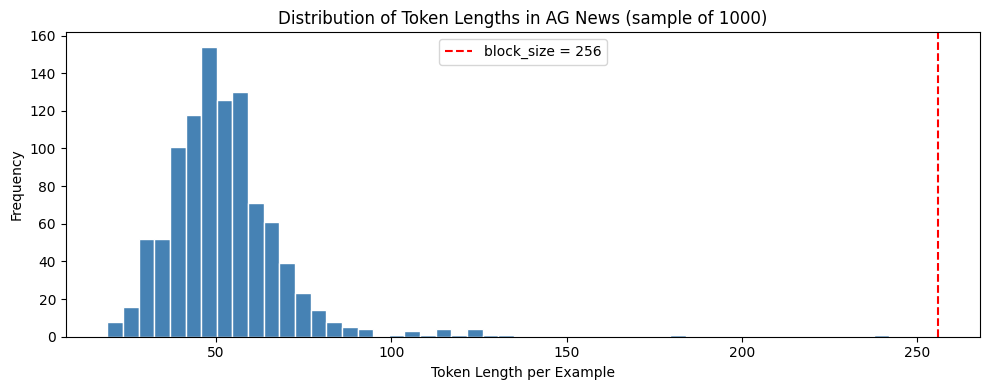

Plot saved as token_length_distribution.png


In [12]:
#---------------------------------------------------------------
# Dataset Statistics (NEW - not in original)
# ---------------------------------------------------------------
# WHY: Understanding your data is critical in MLOps.
#   visualize token count distribution to understand
#   how much text each news example contains before chunking.
#   This helps justify our block_size choice.

import matplotlib.pyplot as plt

# Sample 1000 examples for speed
sample = train_data.select(range(1000))
token_lengths = [len(tokenizer(ex["text"])["input_ids"]) for ex in sample]

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(BLOCK_SIZE, color="red", linestyle="--", label=f"block_size = {BLOCK_SIZE}")
plt.xlabel("Token Length per Example")
plt.ylabel("Frequency")
plt.title("Distribution of Token Lengths in AG News (sample of 1000)")
plt.legend()
plt.tight_layout()
plt.savefig("token_length_distribution.png", dpi=150)
plt.show()
print("Plot saved as token_length_distribution.png")